<a href="https://colab.research.google.com/github/zzzbky03/econ5200-lab05-risk-model/blob/main/lab_ch05_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Diagnosing a Flawed Risk Model

**ECON 5200 — Causal Machine Learning & Applied Analytics**

*Chapter 5: Probability and Simulation*

Estimated time: about 75 minutes (Parts 0–4: 60, the AI section: 15)

---

## Learning Objectives

1. Identify distributional assumptions that underestimate tail risk
2. Compute Expected Shortfall and compare it to VaR
3. Apply variance reduction techniques to Monte Carlo simulation
4. Read and run a reusable risk module (`.py`)

---

**Format:** This lab uses a **diagnosis-first** approach. You are handed a junior risk analyst's report. The code runs without errors, but the risk estimates are too optimistic. Your job is to find out why from the output and explain it. The corrected calculations and the extension are given: you run them and interpret what they print.

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

> ### What you write, and what you run
>
> **You write, in text cells:**
> - **Part 1:** two short answers about what the descriptive statistics say.
> - **Parts 2 and 3:** three interpretation answers each.
> - **The AI Expansion:** you revise the given prompt once, and write four short answers about the AI's backtest, including a check against your own count.
>
> **You run and read:** every code cell in Parts 0–4. They are the analyst's report, the corrected calculations, and the finished `risk_metrics.py` module, which is working code to learn from, not to retype. Read each cell before you run it: the questions ask about what it prints.
>
> **Code you write yourself (optional this week):** the "Write it yourself" exercise after Part 4, about four lines. Writing code from a blank cell is what Problem Set 1 grades; its ungraded warm-up, linked from the PS1 assignment, is the practice.

## Setup

In [27]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

This lab simulates a portfolio and asks you to find what is wrong with a risk
model. Everything in it rests on random draws, so it rests on NumPy, and on
getting reproducibility right, which is the difference between a result and an
anecdote.

**This lab's slice of the floor:** NumPy arrays, seeds and the modern
Generator API, `np.where`, and the one-line comprehension.

### Step 0a: arrays, seeds, and the Generator

A **NumPy array** looks like a list, but arithmetic applies to every element at
once, with no loop. Nearly every number in this course sits in one, including
inside pandas.

A **seed** is where the random number generator starts. The draws are not
really random: they are a fixed sequence, and the seed says where to begin. That
is why every lab seeds: you, your classmate and your grader draw the same
"random" numbers, so results reproduce. 42 is a convention, nothing more.

NumPy has two ways to draw. This lab uses the modern one, a **Generator**:
`demo = np.random.default_rng(seed=42)`, then `demo.normal(...)`. The older way,
`np.random.seed(42)` then `np.random.normal(...)`, uses one generator shared by
the whole program. Prefer the Generator: each one is separate, so one
function's draws cannot disturb another's.

**Reading the prints.** In an f-string, `{x:.4f}` shows four decimals, `{x:.2%}`
shows a percent, `{x:,}` adds thousands separators, `{x:+.5f}` always shows the
sign, and `{x:>14,.0f}` right-aligns the number in 14 characters. Two strings
written side by side, as in a `print` split over two lines, are joined into one.

In [28]:
# GUIDED — run as-is
# Step 0a: arrays, seeds, and the Generator

returns = np.array([0.012, -0.008, 0.003, -0.021, 0.015])
print("returns      :", returns)
print("as percent   :", returns * 100)     # every element at once, no loop
# ddof=1 divides by n - 1: the sample standard deviation
print("mean / std   :", f"{returns.mean():.4f} / {returns.std(ddof=1):.4f}")
print("worst        :", f"{returns.min():.4f}")

demo = np.random.default_rng(seed=42)
a = demo.normal(0, 1, size=5)

demo = np.random.default_rng(seed=42)      # same seed, rebuilt
b = demo.normal(0, 1, size=5)
# np.allclose is True when two arrays match element by element
print(f"\nSame seed reproduces the draw: {np.allclose(a, b)}")
print("draws:", a.round(4))

# The two distributions this lab uses
print("\nnormal   :", demo.normal(0, 0.012, 3).round(4))
print("student-t:", (demo.standard_t(df=4, size=3) * 0.012).round(4))

returns      : [ 0.012 -0.008  0.003 -0.021  0.015]
as percent   : [ 1.2 -0.8  0.3 -2.1  1.5]
mean / std   : 0.0002 / 0.0149
worst        : -0.0210

Same seed reproduces the draw: True
draws: [ 0.3047 -1.04    0.7505  0.9406 -1.951 ]

normal   : [-0.0156  0.0015 -0.0038]
student-t: [-0.0003  0.01    0.009 ]


### Step 0b: `np.where`, and the one-line if/else

`np.where(condition, value_if_true, value_if_false)` applies an if/else to a
whole array at once. It nests, which is how three-way labels get built.

A **ternary**, `A if condition else B`, is the same idea for a single value. It
produces a value, so you can store it in a variable.

A **list comprehension**, `[expression for x in source]`, builds a new list in
one line. Read it as "this expression, for every x in source".

In [29]:
# GUIDED — run as-is
# Step 0b: np.where, and the one-line if/else

sample = np.array([0.012, -0.008, 0.003, -0.021, 0.015])

print("gain/loss   :", np.where(sample > 0, "gain", "loss"))
print("severity    :", np.where(sample < -0.02, "severe",
                       np.where(sample < 0, "mild", "none")))

worst = sample.min()
status = "breach" if worst < -0.02 else "within tolerance"
print(f"\nworst day {worst:.3f}: {status}")

confidences = [0.90, 0.95, 0.99]
labels = [f"{c:.0%} VaR" for c in confidences]
print("labels      :", labels)

gain/loss   : ['gain' 'loss' 'gain' 'loss' 'gain']
severity    : ['none' 'mild' 'none' 'severe' 'none']

worst day -0.021: breach
labels      : ['90% VaR', '95% VaR', '99% VaR']


### Step 0c: historical VaR, done correctly

Part 1 hands you a risk report whose VaR rests on an assumption the data does
not support. Here is the assumption-free version. Run it first.

**Value at Risk (VaR) at 99%** is the loss you exceed on 1% of days. Computed
from the data itself it is just a quantile, with no distribution assumed: the
1st percentile of the returns. **Expected Shortfall (ES)** is the *average*
return on the days at or beyond that threshold, which answers "and how bad is
it when it is bad?" Here both are returns, so they print as negative numbers.
From Part 1 on, VaR and ES are reported as positive losses.

The returns are drawn from a Student-t, which has fatter tails than a normal,
as real asset returns do. The last lines ask what the 99% VaR would be if you
assumed a normal distribution instead.

In [30]:
# GUIDED — run as-is
# Step 0c: historical VaR, done correctly

sim_rng = np.random.default_rng(seed=7)
n = 100_000                       # underscores are legal in numbers: 100000
r = sim_rng.standard_t(df=4, size=n) * 0.012 + 0.0004

var99_hist = np.percentile(r, 1)
# r[r <= var99_hist] keeps only the days at or below the VaR
es99_hist = r[r <= var99_hist].mean()

print(f"simulated days      : {n:,}")
print(f"mean daily return   : {r.mean():+.5f}")
print(f"std daily return    : {r.std(ddof=1):.5f}")
print(f"\n99% VaR (historical): {var99_hist:.4f}  ({var99_hist:.2%})")
print(f"99% ES  (historical): {es99_hist:.4f}  ({es99_hist:.2%})")
print(f"ES / VaR ratio      : {es99_hist / var99_hist:.2f}x")

# norm.ppf is the inverse of the normal CDF: the value with 1% of the curve below it
var99_normal = stats.norm.ppf(0.01, loc=r.mean(), scale=r.std(ddof=1))
beyond = r <= var99_normal        # True on each day worse than the normal VaR
print(f"\n99% VaR if you assume normal: {var99_normal:.4f}  ({var99_normal:.2%})")
print(f"Understatement vs historical: {1 - var99_normal / var99_hist:.1%}")
# .sum() of True/False counts the Trues; .mean() is the share that is True
print(f"Days beyond the normal VaR  : {beyond.sum():,} ({beyond.mean():.2%})")

simulated days      : 100,000
mean daily return   : +0.00046
std daily return    : 0.01688

99% VaR (historical): -0.0443  (-4.43%)
99% ES  (historical): -0.0622  (-6.22%)
ES / VaR ratio      : 1.40x

99% VaR if you assume normal: -0.0388  (-3.88%)
Understatement vs historical: 12.5%
Days beyond the normal VaR  : 1,540 (1.54%)


### Now diagnose

That last block is the whole lab in miniature. The normal-assumption VaR is
12.5% smaller than the historical one, and 1.54% of days fall beyond it, not the
1% a 99% VaR promises.

Keep those numbers. Part 1 presents an analyst's report built on exactly this
mistake, stated with enough confidence that the error is easy to miss. It is in
the *assumption*, not in any line of code. The code runs fine. That is what
makes it dangerous.

---

## Part 1: Find the Bug — VaR Under Normal Assumptions (~15 min)

A junior risk analyst has built a Value at Risk (VaR) model for a portfolio. The code runs without errors and produces a clean report. But the model **dangerously underestimates tail risk** because it assumes returns are normally distributed.

Your task:
1. Run the analyst's code and read the report
2. Run the three cells after it, which describe the returns, plot them against the normal curve, and compare the normal VaR with the actual quantiles
3. Answer the two questions in Step 1: **why** does the normal VaR get the risk wrong?

### The Analyst's Report

The analyst has been handed 2,520 daily returns (about ten years) and reports
these descriptive statistics for the series:

| Statistic | Value |
|-----------|-------|
| Mean daily return | 0.0271% |
| Std deviation | 1.2003% |
| Skewness | +0.281 |
| Excess kurtosis | 4.283 |
| Min daily return | -5.2404% |
| Max daily return | +10.1711% |

Every number in that table is reproduced by the Step 1 cell below, so you can
check the analyst's arithmetic rather than take it on trust.

**Key observation:** The excess kurtosis is 4.28. A normal distribution has
excess kurtosis of 0. This means the tails are **much fatter** than a bell
curve predicts.

The analyst's code ignores this entirely.

> **A note on the simulation.** The series is drawn from a scaled Student-t
> with 5 degrees of freedom, which reproduces the fat tails of equity returns
> but not their asymmetry: a t is symmetric, so the sample skewness here
> (+0.28) is sampling noise around zero rather than a feature. Real S&P 500
> daily returns are *negatively* skewed, roughly -0.3, with the largest moves
> on the downside. That makes the problem you are about to diagnose worse, not
> better — so treating the series as symmetric is the conservative choice.

In [31]:
# THE ANALYST'S CODE — runs without errors, but is FLAWED

# The analyst received this data but did NOT examine its distribution
rng_data = np.random.default_rng(seed=42)
n_days = 2520                     # about 10 years of trading days

# Student-t with 5 df (fat tails). A t(5) has variance 5/3, so dividing by
# sqrt(5/3) gives std 1; then shift and scale to an S&P-like mean and std.
raw_t = rng_data.standard_t(df=5, size=n_days)
daily_returns = 0.0004 + 0.012 * (raw_t / np.sqrt(5/3))

# The analyst's VaR calculation
mu_hat = daily_returns.mean()
sigma_hat = daily_returns.std()
portfolio_value = 10_000_000      # $10M portfolio

# VaR as a positive loss: minus the return at the 1% (or 5%) point of a normal
z_99 = stats.norm.ppf(0.01)       # -2.326
normal_var_99 = -(mu_hat + z_99 * sigma_hat)

z_95 = stats.norm.ppf(0.05)       # -1.645
normal_var_95 = -(mu_hat + z_95 * sigma_hat)

print("="*55)
print("  RISK REPORT — Normal VaR (Analyst's Version)")
print("="*55)
print(f"  Portfolio value:     ${portfolio_value:>14,.0f}")
print(f"  Mean daily return:   {mu_hat:>14.4%}")
print(f"  Std daily return:    {sigma_hat:>14.4%}")
print(f"  ---")
print(f"  95% Normal VaR:      ${normal_var_95 * portfolio_value:>14,.0f}")
print(f"  99% Normal VaR:      ${normal_var_99 * portfolio_value:>14,.0f}")
print("="*55)
print("\nConclusion: Maximum expected daily loss at 99%")
print(f"confidence is ${normal_var_99 * portfolio_value:,.0f}.")
print("Risk is well within acceptable limits.")

  RISK REPORT — Normal VaR (Analyst's Version)
  Portfolio value:     $    10,000,000
  Mean daily return:          0.0271%
  Std daily return:           1.2003%
  ---
  95% Normal VaR:      $       194,720
  99% Normal VaR:      $       276,519

Conclusion: Maximum expected daily loss at 99%
confidence is $276,519.
Risk is well within acceptable limits.


### Step 1: Diagnose the Flaw

The code runs. The numbers look reasonable. But the analyst made a critical error.

The cell below computes the descriptive statistics of `daily_returns`. Run it,
then answer the two questions under it.

In [32]:
# GIVEN — run as-is
# stats.kurtosis reports EXCESS kurtosis, so a normal distribution scores 0

print("Descriptive Statistics of Daily Returns:")
print(f"  Mean:             {daily_returns.mean():.4%}")
print(f"  Std:              {daily_returns.std():.4%}")
print(f"  Skewness:         {stats.skew(daily_returns):.3f}")
print(f"  Excess Kurtosis:  {stats.kurtosis(daily_returns):.3f}")
print(f"  Min:              {daily_returns.min():.4%}")
print(f"  Max:              {daily_returns.max():.4%}")

Descriptive Statistics of Daily Returns:
  Mean:             0.0271%
  Std:              1.2003%
  Skewness:         0.281
  Excess Kurtosis:  4.283
  Min:              -5.2404%
  Max:              10.1711%


**Q1:** What does an excess kurtosis well above 0 tell you about the tails?

The tails are much fatter than a normal distribution's, so extreme days happen far more often than a bell curve predicts. For example, the worst day is about 4.4 standard deviations below the mean, which a normal would almost never produce.


**Q2:** A normal distribution has excess kurtosis 0. The data has 4.28. What
happens to a VaR computed under a normal assumption?

It will underestimates risk: the normal VaR is 276,519 vs. the historical 316,912, about 12.7% too small. At 95% it is actually 3.5% too large, so a 95% check would make the model look safe while it still understates 99% risk.

### Step 2: Visualize the Problem

The cell below draws the returns as a histogram, with the normal curve the
analyst assumed on top. The right panel is the same chart zoomed into the worst
5% of days, where VaR lives, so bars and curve stay on the same scale.

In the zoom, look at where the bars rise above the red curve and where they
fall short of it. The bars are higher than the curve in the far tail, below
about −3%, and mostly lower than it between there and the 5% cutoff. Step 3 turns that
picture into numbers.

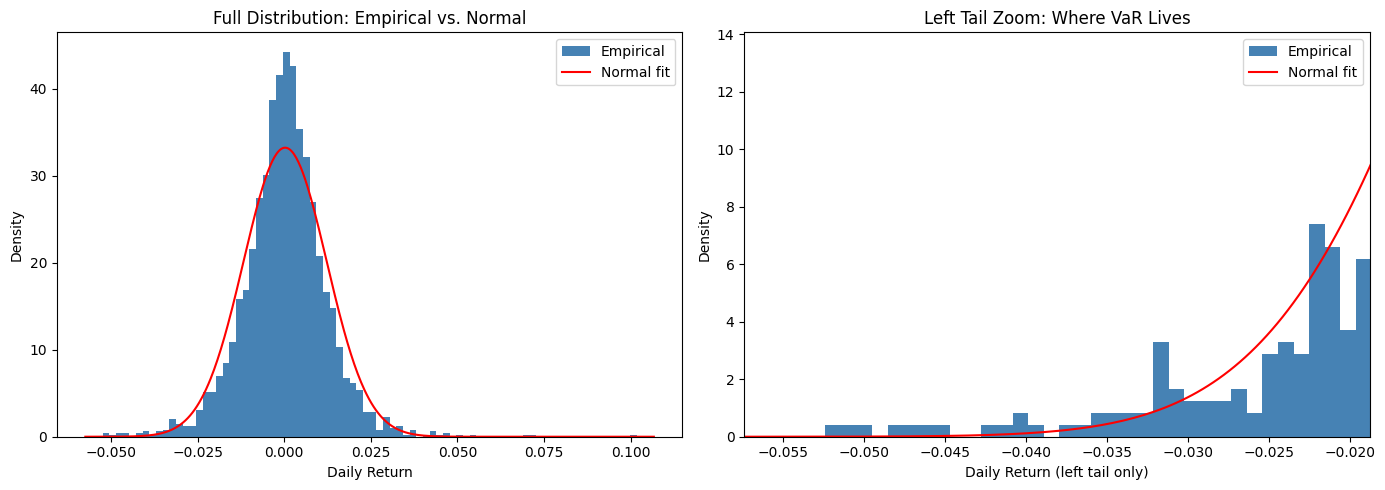

In [33]:
# GIVEN — run as-is

x_grid = np.linspace(daily_returns.min() - 0.005, daily_returns.max() + 0.005, 500)
tail_cutoff = np.percentile(daily_returns, 5)


def hist_vs_normal(ax, bins):
    """Histogram of daily_returns with the analyst's fitted normal drawn over it."""
    ax.hist(daily_returns, bins=bins, density=True, color="steelblue", label="Empirical")
    ax.plot(x_grid, stats.norm.pdf(x_grid, loc=mu_hat, scale=sigma_hat),
            color="red", label="Normal fit")
    ax.set_ylabel("Density")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_vs_normal(axes[0], bins=80)
axes[0].set_xlabel("Daily Return")
axes[0].set_title("Full Distribution: Empirical vs. Normal")

# Same chart with narrower bins, cut at the 5th percentile; the y-axis stops a
# little above the normal curve's height at the cutoff
hist_vs_normal(axes[1], bins=160)
axes[1].set_xlim(x_grid[0], tail_cutoff)
axes[1].set_ylim(0, 1.5 * stats.norm.pdf(tail_cutoff, loc=mu_hat, scale=sigma_hat))
axes[1].set_xlabel("Daily Return (left tail only)")
axes[1].set_title("Left Tail Zoom: Where VaR Lives")

plt.tight_layout()
plt.show()

### Step 3: Quantify the Underestimation — and Where It Does Not Happen

The cell below compares the normal VaR with the actual (historical) quantile,
at *both* confidence levels. They do not tell the same story.

A fat-tailed distribution matched to a normal on mean and standard deviation
has to buy its heavy tails from somewhere. It buys them from the *shoulders*:
the scaled Student-t puts more mass far out and more mass near the centre, and
correspondingly **less** mass in the region a couple of standard deviations
out. So there is a confidence level at which the two quantiles cross.

For a Student-t with 5 degrees of freedom standardised to unit variance, the
crossover is at the **2.92%** quantile — the 97.1% confidence level. Deeper
than that, the t is more extreme than the normal and the normal VaR is too
small. Shallower than that, the *normal* quantile is the more extreme one and
the normal VaR is too **large**.

99% is deeper than the crossover. 95% is shallower. Predict the sign of each
comparison before you run the cell. The Step 2 zoom is your evidence.

In [34]:
# GIVEN — run as-is
# Historical VaR: minus the actual 1st and 5th percentiles of the returns
historical_var_99 = -np.percentile(daily_returns, 1)
historical_var_95 = -np.percentile(daily_returns, 5)

# Positive gap: the normal VaR is below the historical one (too small)
gap_99 = (historical_var_99 - normal_var_99) / historical_var_99
gap_95 = (historical_var_95 - normal_var_95) / historical_var_95
dollar_gap = (historical_var_99 - normal_var_99) * portfolio_value

print("99% VaR ($10M portfolio)")
print(f"  Normal assumption:   ${normal_var_99 * portfolio_value:>12,.0f}")
print(f"  Historical (actual): ${historical_var_99 * portfolio_value:>12,.0f}")
print(f"  Gap, as a share of historical: {gap_99:.1%}")
print()
print("95% VaR ($10M portfolio)")
print(f"  Normal assumption:   ${normal_var_95 * portfolio_value:>12,.0f}")
print(f"  Historical (actual): ${historical_var_95 * portfolio_value:>12,.0f}")
print(f"  Gap, as a share of historical: {gap_95:.1%}")
print()
print(f"99% VaR shortfall under the normal: ${dollar_gap:,.0f}")

99% VaR ($10M portfolio)
  Normal assumption:   $     276,519
  Historical (actual): $     316,912
  Gap, as a share of historical: 12.7%

95% VaR ($10M portfolio)
  Normal assumption:   $     194,720
  Historical (actual): $     188,212
  Gap, as a share of historical: -3.5%

99% VaR shortfall under the normal: $40,393


### Verification Checkpoint 1

With `seed=42` and `n_days=2520`, the measured values are:

| Measure | Normal VaR ($10M) | Historical VaR ($10M) | Normal is |
|---------|------------------:|----------------------:|-----------|
| 95% VaR | $194,720 | $188,212 | 3.5% too **large** (gap −3.5%) |
| 99% VaR | $276,519 | $316,912 | 12.7% too **small** (gap 12.7%) |

The gap is positive when the normal VaR is too small and negative when it is
too large.

Two checks, and they point opposite ways on purpose:

- The historical **99%** VaR must be **larger** than the normal 99% VaR — that
  is the fat-tail failure, and it is worth about $40,000 of capital on a $10M
  book.
- The historical **95%** VaR must be **smaller** than the normal 95% VaR. This
  is not a bug and not a bad seed: 95% sits on the *thin* side of the 2.92%
  crossover for a standardised t(5). It holds for the distribution itself, and
  for about 98% of 2,520-day samples drawn from it; in the rest, sampling noise
  flips it.

Put the two together. A bank using this model would hold less capital than it
needs at 99%, and its own 95% backtest would have told it the model was
conservative. Passing at 95% is not evidence of safety at 99%.

The check below asks for excess kurtosis above 2 (measured 4.28; a normal
scores 0). Sample skewness should be near zero (measured +0.28); the
underlying t is symmetric.

In [35]:
# CHECK — run as-is

checks = {
    "Excess kurtosis > 2 (fat tails)": stats.kurtosis(daily_returns) > 2,
    "Historical 99% VaR > Normal 99% VaR": historical_var_99 > normal_var_99,
    "Normal understates 99% VaR by > 10%": gap_99 > 0.10,
    # Shallower than the 2.92% crossover the sign flips: expected, see Checkpoint 1
    "Historical 95% VaR < Normal 95% VaR (thin shoulders)":
        historical_var_95 < normal_var_95,
}

for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {name}")

print()
# all() is True only when every value in the dict is True
if all(checks.values()):
    print("All Part 1 checks passed.")

  [PASS] Excess kurtosis > 2 (fat tails)
  [PASS] Historical 99% VaR > Normal 99% VaR
  [PASS] Normal understates 99% VaR by > 10%
  [PASS] Historical 95% VaR < Normal 95% VaR (thin shoulders)

All Part 1 checks passed.


---

## Part 2: Fix It — Compare VaR and ES (~10 min)

Now that you have diagnosed the flaw, the next two cells compute both **VaR** and **Expected Shortfall (ES)** under three distributional assumptions:

1. **Normal** — the analyst's flawed assumption
2. **Student-t** — fit degrees of freedom from the data
3. **Historical simulation** — use the empirical distribution directly

**Why ES?** The Basel Committee's Fundamental Review of the Trading Book (FRTB, published 2016, revised 2019) replaces 99% VaR with 97.5% Expected Shortfall for market-risk capital. VaR tells you the *threshold* of a bad day; ES tells you how bad an average bad day beyond it actually is. ES is always >= VaR.

In [36]:
# GIVEN — run as-is
# stats.t.fit finds the (df, loc, scale) that make the data most likely (maximum likelihood)
df_hat, loc_hat, scale_hat = stats.t.fit(daily_returns)

print("Student-t MLE fit:")
print(f"  Degrees of freedom: {df_hat:.2f}")
print(f"  Location (mu):      {loc_hat:.6f}")
print(f"  Scale (sigma):      {scale_hat:.6f}")

Student-t MLE fit:
  Degrees of freedom: 4.58
  Location (mu):      0.000305
  Scale (sigma):      0.009077


The fitted degrees of freedom come out near 4.6; the data were drawn with 5. A
normal distribution is the limit as df goes to infinity, so a low df means fat
tails, and df = 5 is very fat-tailed.

The next cell computes 99% VaR and ES three ways and puts them side by side.
Read how each method gets its ES: a formula for the normal, a large simulation
from the fitted t, and a plain average of the worst days for historical.

In [37]:
# GIVEN — run as-is

confidence = 0.99
alpha = 1 - confidence            # 0.01, the tail probability

# Normal: the analyst's VaR, and the closed-form mean of the normal tail beyond it
normal_var = -(mu_hat + stats.norm.ppf(alpha) * sigma_hat)
normal_es = -(mu_hat - sigma_hat * stats.norm.pdf(stats.norm.ppf(alpha)) / alpha)

# Student-t: VaR from the fitted quantile; ES by averaging the tail of 500,000 draws
t_quantile = stats.t.ppf(alpha, df=df_hat, loc=loc_hat, scale=scale_hat)
t_var = -t_quantile
rng_es = np.random.default_rng(seed=42)
t_samples = stats.t.rvs(df=df_hat, loc=loc_hat, scale=scale_hat,
                        size=500_000, random_state=rng_es)
t_es = -t_samples[t_samples <= t_quantile].mean()

# Historical: the empirical quantile, and the mean of the days at or beyond it
hist_var = -np.percentile(daily_returns, alpha * 100)
hist_es = -daily_returns[daily_returns <= -hist_var].mean()

# Each dict key becomes a column; arrays make each column one multiplication
var_all = np.array([normal_var, t_var, hist_var])
es_all = np.array([normal_es, t_es, hist_es])
results = pd.DataFrame({
    "Method": ["Normal", "Student-t", "Historical"],
    "VaR (%)": var_all * 100,
    "VaR ($)": var_all * portfolio_value,
    "ES (%)": es_all * 100,
    "ES ($)": es_all * portfolio_value,
})

print("99% RISK MEASURES ($10M portfolio)")


def one_decimal(x):
    return f"{x:.1f}"


def whole_dollars(x):
    return f"{x:,.0f}"


# formatters maps each column to the function that writes its numbers
print(results.to_string(index=False, formatters={
    "VaR (%)": one_decimal, "VaR ($)": whole_dollars,
    "ES (%)": one_decimal, "ES ($)": whole_dollars,
}))

99% RISK MEASURES ($10M portfolio)
    Method VaR (%) VaR ($) ES (%)  ES ($)
    Normal     2.8 276,519    3.2 317,193
 Student-t     3.1 314,571    4.3 426,060
Historical     3.2 316,912    3.9 391,464


### Interpretation Questions

**Q1:** Why is ES always greater than or equal to VaR for the same confidence level?

Because ES is the average of all the losses that are at or past the VaR. All of those losses are at least as big as the VaR, so the average can't be smaller than it. In our results the historical ES is $391,464, compared with a VaR of $316,912.


**Q2:** The Basel Committee switched from 99% VaR to 97.5% ES. Why use a *lower* confidence level for ES? (Hint: ES already captures tail severity.)

ES already looks at how bad the whole tail is, so it doesn't need to go as far out as 99%. For a normal distribution, 97.5% ES ends up close to 99% VaR, so it only asks for more capital when the tails are fat. It also uses more data points, so the estimate is more stable.


**Q3:** Which of the three methods (Normal, Student-t, Historical) would you recommend for a bank's internal risk model? Why?

I would pick the Student-t and use historical as a check. The normal model clearly underestimates the risk. The t fit (df = 4.58) handles fat tails, its VaR is close to the historical one, and it gives the highest ES ($426,060), which is safer. Historical only has about 25 tail days, and it can't show a loss bigger than the worst day we've already seen.


### Verification Checkpoint 2

Expected ranges for the 99% measures on a $10M portfolio, with the values
measured at `seed=42`:

| Method | VaR ($) | ES ($) | Measured VaR | Measured ES |
|--------|---------|--------|-------------:|------------:|
| Normal | $265K–$285K | $300K–$330K | $276,519 | $317,193 |
| Student-t | $310K–$400K | $400K–$550K | $314,571 | $426,060 |
| Historical | $300K–$370K | $380K–$500K | $316,912 | $391,464 |

The checks below confirm:
- ES > VaR for **every** method
- Student-t VaR > Normal VaR (fat tails shift the quantile)
- Student-t ES is the **largest**, above both the normal and the historical ES
  (the t has the fattest modeled tails)
- The fitted df is between 3 and 10 (measured 4.58)

In [38]:
# CHECK — run as-is

checks_p2 = {
    "ES > VaR (Normal)": normal_es > normal_var,
    "ES > VaR (Student-t)": t_es > t_var,
    "ES > VaR (Historical)": hist_es > hist_var,
    "Student-t VaR > Normal VaR": t_var > normal_var,
    "Fitted df between 3 and 10": 3 < df_hat < 10,
    "Student-t ES > Normal ES": t_es > normal_es,
    "Student-t ES > Historical ES": t_es > hist_es,
}

for name, passed in checks_p2.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {name}")

print()
if all(checks_p2.values()):
    print("All Part 2 checks passed.")

  [PASS] ES > VaR (Normal)
  [PASS] ES > VaR (Student-t)
  [PASS] ES > VaR (Historical)
  [PASS] Student-t VaR > Normal VaR
  [PASS] Fitted df between 3 and 10
  [PASS] Student-t ES > Normal ES
  [PASS] Student-t ES > Historical ES

All Part 2 checks passed.


---

## Part 3: Extend — Variance Reduction with Antithetic Variates (~10 min)

Monte Carlo simulation converges at $O(1/\sqrt{n})$ — to halve the standard error, you need 4x the samples. **Variance reduction techniques** improve efficiency without more samples.

**Scenario:** Price a European call option using Monte Carlo. The payoff is $\max(S_T - K, 0)$ where:
- $S_0 = 100$ (current stock price)
- $K = 105$ (strike price)
- $r = 0.05$ (risk-free rate, annual)
- $\sigma = 0.20$ (volatility, annual)
- $T = 1$ year

Under geometric Brownian motion:
$$S_T = S_0 \exp\left((r - \sigma^2/2)T + \sigma\sqrt{T} \cdot Z\right), \quad Z \sim N(0,1)$$

The next three cells are given. They:
1. Estimate the discounted expected payoff with **naive Monte Carlo**
2. Do the same with **antithetic variates**: draw half as many $Z$ and pair each with $-Z$
3. Compare the two standard errors with each other and the two prices with the exact
   Black-Scholes price

Your work is the interpretation questions after them.

In [39]:
# GIVEN — run as-is
# Naive Monte Carlo: price a call option from independent normal draws

S0 = 100       # current price
K = 105        # strike price
r = 0.05       # risk-free rate
sigma = 0.20   # volatility
T = 1.0        # time to expiry (years)
n_sims = 50_000


def call_payoff(Z):
    """Call payoff max(S_T - K, 0) at the terminal prices set by the draws Z."""
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    # np.maximum works element by element: each path gets its own max(..., 0)
    return np.maximum(ST - K, 0)


rng_mc = np.random.default_rng(seed=42)
Z_naive = rng_mc.standard_normal(n_sims)
discounted_naive = np.exp(-r * T) * call_payoff(Z_naive)

price_naive = discounted_naive.mean()
se_naive = discounted_naive.std() / np.sqrt(n_sims)

print("Naive Monte Carlo (50,000 simulations):")
print(f"  Call price estimate: ${price_naive:.4f}")
print(f"  Standard error:      ${se_naive:.4f}")
print(f"  95% CI: [${price_naive - 1.96*se_naive:.4f}, ${price_naive + 1.96*se_naive:.4f}]")

Naive Monte Carlo (50,000 simulations):
  Call price estimate: $8.0369
  Standard error:      $0.0593
  95% CI: [$7.9206, $8.1531]


In [40]:
# GIVEN — run as-is
# Antithetic variates: Z and -Z push the price in opposite directions, so
# the average of each pair varies less than two independent draws would

rng_anti = np.random.default_rng(seed=42)
n_pairs = n_sims // 2             # // divides and drops any remainder: 25,000 pairs

Z_half = rng_anti.standard_normal(n_pairs)

# Average each pair first: the pair, not the path, is one independent observation
paired_avg = (call_payoff(Z_half) + call_payoff(-Z_half)) / 2
discounted_anti = np.exp(-r * T) * paired_avg

price_anti = discounted_anti.mean()
se_anti = discounted_anti.std() / np.sqrt(n_pairs)

print("Antithetic Variates (25,000 pairs = 50,000 paths):")
print(f"  Call price estimate: ${price_anti:.4f}")
print(f"  Standard error:      ${se_anti:.4f}")
print(f"  95% CI: [${price_anti - 1.96*se_anti:.4f}, ${price_anti + 1.96*se_anti:.4f}]")

Antithetic Variates (25,000 pairs = 50,000 paths):
  Call price estimate: $8.0246
  Standard error:      $0.0471
  95% CI: [$7.9323, $8.1169]


In [41]:
# GIVEN — run as-is

# Black-Scholes closed form: the exact price both estimates aim at
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_price = S0 * stats.norm.cdf(d1) - K * np.exp(-r*T) * stats.norm.cdf(d2)

se_ratio = se_naive / se_anti
variance_reduction = 1 - (se_anti / se_naive)**2
# SE falls with sqrt(n), so naive MC needs se_ratio**2 times the draws to match
naive_draws_needed = int(n_sims * se_ratio**2)

print(f"Black-Scholes exact: ${bs_price:.4f}")
print(f"Naive MC estimate:   ${price_naive:.4f}  (SE = {se_naive:.4f})")
print(f"Antithetic estimate: ${price_anti:.4f}  (SE = {se_anti:.4f})")
print()
print(f"SE reduction factor: {se_ratio:.2f}x")
print(f"Variance reduction:  {variance_reduction:.1%}")
print(f"Naive draws for the same SE: {naive_draws_needed:,} "
      f"(~{se_ratio**2:.1f}x {n_sims:,})")

Black-Scholes exact: $8.0214
Naive MC estimate:   $8.0369  (SE = 0.0593)
Antithetic estimate: $8.0246  (SE = 0.0471)

SE reduction factor: 1.26x
Variance reduction:  37.0%
Naive draws for the same SE: 79,326 (~1.6x 50,000)


### Interpretation

**Q1:** By what factor did antithetic variates reduce the standard error? Express as a ratio (SE_naive / SE_antithetic).

SE_naive / SE_antithetic = 0.0593 / 0.0471 ≈ 1.26x. That's about a 37% cut in variance, so naive MC would need around 79,000 draws to get the same SE.


**Q2:** Why does pairing $Z$ with $-Z$ reduce variance? (Hint: think about correlation between payoff($Z$) and payoff($-Z$).)

The call payoff goes up when Z goes up, so if Z gives a high payoff, −Z usually gives a low one. That makes the two payoffs negatively correlated, and when we average each pair their errors partly cancel out. The effect isn't huge here because the payoff is cut off at 0: when both paths end out of the money, both pay 0 and nothing cancels.

**Q3:** Would antithetic variates help if the payoff function were symmetric around the mean? Why or why not?

No. If the payoff is symmetric, payoff(Z) and payoff(−Z) are exactly the same, so the correlation is +1. The second path doesn't add any new information, and we'd basically only have 25,000 draws instead of 50,000, so the SE would actually be worse than naive MC


### Verification Checkpoint 3

Expected results with `seed=42` and `n_sims=50_000`:

| Measure | Naive MC | Antithetic |
|---------|----------|------------|
| Call price | $7.95–$8.10 | $7.95–$8.10 |
| Standard error | $0.055–$0.065 | $0.043–$0.052 |
| SE reduction factor | — | 1.2x–1.35x |

Measured at `seed=42`, `n_sims=50_000`: naive **$8.0369 (SE 0.0593)**,
antithetic **$8.0246 (SE 0.0471)**, reduction **1.26x**, variance reduction
**37.0%**. The Black-Scholes exact price is **$8.0214**, and both estimates sit
within one standard error of it.

Key check: the antithetic SE should be **at least 1.2x smaller** than the naive
SE.

Do not expect a large reduction. Antithetic pairs cancel best when the payoff is
close to linear in $Z$, so that a high draw and its mirror miss by equal and
opposite amounts. A call payoff is `max(S - K, 0)`, which is **truncated at zero**:
when both paths of a pair finish out of the money, both pay nothing and there is
nothing to cancel, so the correlation within a pair is well short of −1 and the
reduction is modest. 1.26x is the right answer for this payoff, not a sign that
something is wrong.

---

## Part 4: The Risk Module — `risk_metrics.py` (~10 min)

Here is the finished module. It puts the Part 2 calculations behind three
functions and saves them as an importable `.py` file, which is part of what you
submit. Read it against your Part 2 cell: find where each of the three methods
lives in `calculate_var` and `calculate_es`, and check that the Student-t ES uses
the same seed and sample size as Part 2. Then run it and the two cells below it.

- `calculate_var(returns, confidence, method)`: VaR by the `'historical'`, `'normal'` or `'t'` method
- `calculate_es(returns, confidence, method)`: Expected Shortfall by the same three methods
- `mc_var(mu, sigma, n_sims, confidence, dist, df, seed)`: VaR and ES from simulated normal or t returns
- an `if __name__ == "__main__":` block of self-tests, which runs only when the file is run as a script

Two things to know before you read it. `assert condition, "message"` stops with
that message when the condition is false; the module uses it to reject bad
inputs. And `returns: np.ndarray` or `-> float` are type hints: labels for the
reader that Python does not enforce.

In [42]:
%%writefile risk_metrics.py
"""VaR and Expected Shortfall under historical, normal and Student-t assumptions."""

import numpy as np
from scipy import stats

VALID_METHODS = ('historical', 'normal', 't')
VALID_DISTS = ('normal', 't')


def calculate_var(returns: np.ndarray, confidence: float = 0.99,
                  method: str = 'historical') -> float:
    """Value at Risk as a positive loss, by 'historical', 'normal' or 't'."""
    assert method in VALID_METHODS, f"method must be one of {VALID_METHODS}"
    alpha = 1 - confidence

    if method == 'historical':
        return float(-np.percentile(returns, alpha * 100))
    elif method == 'normal':
        mu = returns.mean()
        sigma = returns.std(ddof=1)
        return float(-(mu + stats.norm.ppf(alpha) * sigma))
    else:
        df_hat, loc_hat, scale_hat = stats.t.fit(returns)
        return float(-stats.t.ppf(alpha, df=df_hat, loc=loc_hat, scale=scale_hat))


def calculate_es(returns: np.ndarray, confidence: float = 0.99,
                 method: str = 'historical') -> float:
    """Expected Shortfall (average loss at or beyond the VaR), by the same three methods."""
    assert method in VALID_METHODS, f"method must be one of {VALID_METHODS}"
    alpha = 1 - confidence

    if method == 'historical':
        var = calculate_var(returns, confidence, method)
        return float(-returns[returns <= -var].mean())
    elif method == 'normal':
        mu = returns.mean()
        sigma = returns.std(ddof=1)
        return float(-(mu - sigma * stats.norm.pdf(stats.norm.ppf(alpha)) / alpha))
    else:
        # Simulated, with the same seed and sample size as Part 2
        df_hat, loc_hat, scale_hat = stats.t.fit(returns)
        rng = np.random.default_rng(seed=42)
        samples = stats.t.rvs(df=df_hat, loc=loc_hat, scale=scale_hat,
                              size=500_000, random_state=rng)
        t_quantile = stats.t.ppf(alpha, df=df_hat, loc=loc_hat, scale=scale_hat)
        return float(-samples[samples <= t_quantile].mean())


def mc_var(mu: float, sigma: float, n_sims: int = 100_000,
           confidence: float = 0.99, dist: str = 'normal',
           df: float = 5.0, seed: int = 42) -> dict:
    """Simulate returns with this mean and std; return {'var': ..., 'es': ...}."""
    assert dist in VALID_DISTS, f"dist must be one of {VALID_DISTS}"
    rng = np.random.default_rng(seed=seed)
    alpha = 1 - confidence

    if dist == 'normal':
        sim_returns = rng.normal(loc=mu, scale=sigma, size=n_sims)
    else:
        # A t with df (above 2) degrees of freedom has std sqrt(df / (df - 2)); rescale it to sigma
        scale_t = sigma * np.sqrt((df - 2) / df)
        sim_returns = mu + scale_t * rng.standard_t(df=df, size=n_sims)

    var = float(-np.percentile(sim_returns, alpha * 100))
    es = float(-sim_returns[sim_returns <= -var].mean())
    return {'var': var, 'es': es}


if __name__ == "__main__":
    # Self-tests on normal returns, where every method should roughly agree
    rng_test = np.random.default_rng(seed=42)
    test_returns = rng_test.normal(loc=0.0004, scale=0.012, size=5000)

    print("risk_metrics.py self-test")
    for method in VALID_METHODS:
        var = calculate_var(test_returns, 0.99, method)
        es = calculate_es(test_returns, 0.99, method)
        print(f"  {method:>12s}  VaR={var:.4%}  ES={es:.4%}")
        assert es >= var, f"ES must be >= VaR for method={method}"

    mc_normal = mc_var(mu=0.0004, sigma=0.012, n_sims=100_000, confidence=0.99)
    print(f"  MC (normal): VaR={mc_normal['var']:.4%}  ES={mc_normal['es']:.4%}")
    assert mc_normal['es'] >= mc_normal['var']

    mc_t = mc_var(mu=0.0004, sigma=0.012, n_sims=100_000,
                  confidence=0.99, dist='t', df=5)
    print(f"  MC (t, df=5): VaR={mc_t['var']:.4%}  ES={mc_t['es']:.4%}")
    assert mc_t['var'] > mc_normal['var'], "t-dist VaR should exceed normal VaR"

    print("All self-tests passed.")

Overwriting risk_metrics.py


In [43]:
# TEST — check the module works on the lab's data

import importlib
import risk_metrics
importlib.reload(risk_metrics)      # reload, so a re-run of the %%writefile cell takes effect
from risk_metrics import calculate_var, calculate_es, mc_var

print("Module verification with lab data:")
print()

for method in ['historical', 'normal', 't']:
    var = calculate_var(daily_returns, 0.99, method)
    es = calculate_es(daily_returns, 0.99, method)
    print(f"  {method:>12s}:  VaR = ${var * portfolio_value:>10,.0f}   "
          f"ES = ${es * portfolio_value:>10,.0f}")
    assert es >= var, f"ES < VaR for {method}"

print()

mc_result = mc_var(mu=0.0004, sigma=0.012, n_sims=100_000, confidence=0.99)
print(f"  MC (normal):  VaR = ${mc_result['var'] * portfolio_value:>10,.0f}   "
      f"ES = ${mc_result['es'] * portfolio_value:>10,.0f}")

mc_fat = mc_var(mu=0.0004, sigma=0.012, n_sims=100_000,
                confidence=0.99, dist='t', df=5)
print(f"  MC (t, df=5): VaR = ${mc_fat['var'] * portfolio_value:>10,.0f}   "
      f"ES = ${mc_fat['es'] * portfolio_value:>10,.0f}")

assert mc_fat['var'] > mc_result['var'], "t-dist should produce larger VaR"
assert mc_fat['es'] > mc_result['es'], "t-dist should produce larger ES"

print()
print("All module tests passed.")

Module verification with lab data:

    historical:  VaR = $   316,912   ES = $   391,464
        normal:  VaR = $   276,575   ES = $   317,257
             t:  VaR = $   314,571   ES = $   426,060

  MC (normal):  VaR = $   277,221   ES = $   318,501
  MC (t, df=5): VaR = $   307,428   ES = $   402,220

All module tests passed.


### Verification Checkpoint 4

What the tests above confirm:

1. ES >= VaR for **every** method
2. `mc_var` with `dist='t'` produces larger VaR and ES than `dist='normal'` (same mu, sigma)

The historical and t rows match Part 2 to the dollar. The normal VaR here,
$276,575, is $56 above Part 2's $276,519: the module takes the standard
deviation with `ddof=1`, and Part 2 reused the analyst's `daily_returns.std()`,
which divides by n.

In [44]:
# Run the module as a script, which runs its __main__ self-tests
!python risk_metrics.py

risk_metrics.py self-test
    historical  VaR=2.7734%  ES=3.1680%
        normal  VaR=2.7739%  ES=3.1804%
             t  VaR=2.7853%  ES=3.2108%
  MC (normal): VaR=2.7722%  ES=3.1850%
  MC (t, df=5): VaR=3.0743%  ES=4.0222%
All self-tests passed.


---

### Write it yourself (optional this week)

This exercise is optional and ungraded this week. It is the one place in this
lab where you write code from a blank cell.

Basel's capital rule measures market risk with **97.5% Expected Shortfall**,
not 99% VaR. In the empty cell below, compute the historical 97.5% VaR and ES of
`daily_returns`, as positive dollar losses on `portfolio_value`. Name them
`var_975` and `es_975`, and print both.

Work from `daily_returns` with NumPy, the way Step 0c and the historical lines of
Part 2 do; do not call `risk_metrics`. It takes about four lines. Then run the
check cell. If you skipped the exercise it says so and moves on; if you wrote
it, it fails until your two numbers are right.

In [45]:
# OPTIONAL — write it yourself

In [46]:
# CHECK — for the optional exercise above
# globals() holds every name defined so far in this notebook
if "var_975" not in globals() or "es_975" not in globals():
    print("Optional exercise not attempted: nothing to check. That is fine this week.")
else:
    # a \ at the end of a line continues the statement on the next line
    assert var_975 > 0 and es_975 > 0, \
        "VaR and ES are losses here: report both as positive dollar amounts."
    assert es_975 >= var_975, \
        "ES averages the days at or beyond the VaR, so it cannot be smaller than the VaR."
    assert abs(var_975 - calculate_var(daily_returns, 0.975) * portfolio_value) < 1, \
        "var_975 is off: check which percentile a 97.5% VaR sits at, and the dollar scaling."
    assert abs(es_975 - calculate_es(daily_returns, 0.975) * portfolio_value) < 1, \
        "var_975 is right but es_975 is off: average only the days at or beyond the VaR."
    print("Both numbers match.")

Optional exercise not attempted: nothing to check. That is fine this week.


---

## Lab Summary

You diagnosed a flawed risk model, compared it with better ones, and ran a
reusable risk module:

| Part | What You Did | Key Takeaway |
|------|-------------|---------------|
| 1 | Found the normal assumption flaw | At 99% the normal VaR is 12.7% too small; at 95% it is 3.5% too large, so a 95% backtest would not catch it |
| 2 | Compared VaR and ES under three distributions | ES captures tail severity; Student-t captures fat tails |
| 3 | Compared naive and antithetic Monte Carlo | Antithetic pairs cut the standard error 1.26x at no extra draws |
| 4 | Read and ran `risk_metrics.py` | The same calculations as importable functions, with self-tests |

**The central lesson:** A model that runs without errors can still be *dangerously wrong* if its distributional assumptions do not match reality. Always check kurtosis before assuming normality.

---
## AI-Assisted Expansion: a VaR backtest written by AI, checked by you

A regulator does not take a VaR figure on trust: it counts how often the bank's
losses went past it. A 99% VaR should be breached on about 1% of days. Ask an AI
to write that backtest, run it on the two 99% VaRs from Part 1, and check it
against a count you make yourself.

**What to do**
1. Copy **prompt version 1** below into Claude ([claude.northeastern.edu](https://claude.northeastern.edu)) or ChatGPT.
2. Read what comes back before you run it. The prompt leaves at least one
   important thing unsaid, so the AI had to guess. Find one guess that is wrong,
   or one that you would rather decide yourself.
3. Write **prompt version 2** in the cell below, fixing that one thing, and ask
   again. Paste the function from version 2 into the empty code cell and run the
   check.
4. Answer the questions at the end. They are what is graded, not the code.

In [47]:
# PROMPT, version 1 — copy it exactly as it is
#
# I have a NumPy array daily_returns of 2,520 daily portfolio returns and a
# one-day 99% Value at Risk. Write a Python function backtest_var(returns, var)
# that returns the share of days on which the loss exceeded the VaR.
# Use NumPy only, and comment each line.

# PROMPT, version 2 — your revision. Keep everything from version 1 that was
# fine, and add or change the part the AI had to guess.
# I have a NumPy array daily_returns of 2,520 daily portfolio returns and a
# one-day 99% Value at Risk. The VaR is reported as a POSITIVE number, a loss
# as a fraction of the portfolio (for example 0.0317 means a 3.17% loss), and
# the returns are negative on losing days. Write a Python function
# backtest_var(returns, var) that returns the share of days on which the loss
# exceeded the VaR, as a fraction between 0 and 1. A day counts as a breach
# only if the loss is strictly greater than the VaR, that is, the return is
# below -var. Do not take the absolute value of returns or VaR, and do not
# print anything. Use NumPy only, and comment each line.
#

In [48]:
# Paste the backtest_var function from your version 2 here, then run the check below.
import numpy as np


def backtest_var(returns, var):
    # Convert input array of daily returns to an explicit NumPy array
    returns = np.asarray(returns)

    # Losses are negative returns, so we negate daily returns to get positive loss values
    losses = -returns

    # Identify days where daily loss strictly exceeded the calculated VaR threshold
    breaches = losses > var

    # Calculate and return the mean of the boolean array, which gives the proportion of breach days
    return np.mean(breaches)

In [49]:
# CHECK — the AI's backtest against a count made by hand
if "backtest_var" not in globals():
    print("Paste the AI's backtest_var function in the cell above first.")
else:
    for name, var in [("historical 99% VaR", historical_var_99), ("normal 99% VaR", normal_var_99)]:
        by_hand = (daily_returns < -var).mean()     # a loss beyond VaR is a return below -VaR
        print(f"{name}: AI {backtest_var(daily_returns, var):.2%}   by hand {by_hand:.2%}")
    print("If a pair differs, find out why before you trust the function.")

historical 99% VaR: AI 1.03%   by hand 1.03%
normal 99% VaR: AI 1.71%   by hand 1.71%
If a pair differs, find out why before you trust the function.


### Document the interaction

This is what is graded for the expansion.

1. **Your revision.** What did you change between version 1 and version 2, and
   what did the AI get wrong or have to guess that made you change it?
2. **The check.** Do the AI's two numbers match the hand counts? Which VaR is
   breached more often than the 1% it promises, and what does that say about the
   analyst's report?
3. **In your own words.** Pick the line or two of the AI's function that decide
   whether a day counts as a breach, and explain in 2–3 sentences what they do.
4. **Would you use AI for this again?** One sentence: when is it worth it, and
   when is it faster to write the function yourself?

*Your answers here:*

1.Version 1 didn't say if the VaR is a positive loss or a negative return, so the AI had to guess. It assumed positive without saying so. That works here, but in Step 0c the VaR was negative (-0.0443), and with that input almost every day would count as a breach. In version 2 I said the VaR is a positive loss and a breach means the return is below -var.

2.Yes, both match. The historical VaR is breached on 1.03% of days, close to 1%. The normal VaR is breached on 1.71% (43 days vs. about 25), so the analyst's "well within limits" claim is wrong.

3.losses = -returns turns bad days into positive losses so they can be compared with the VaR. breaches = losses > var marks the days where the loss is bigger than the VaR, and np.mean(breaches) gives their share.

4.AI helps with longer or unfamiliar code, but for a short function like this it's faster to write it myself since I have to check the sign anyway.

---
## Digital Portfolio: your README

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [50]:
# README prompt — documentation only, no code

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed a junior analyst's normal-distribution VaR model: at 99% it
#   understated historical VaR by [YOUR VALUE]% ($[YOUR VALUE] on the
#   portfolio)
# * Computed VaR and Expected Shortfall under historical, normal and
#   Student-t (fitted df = [YOUR VALUE]) methods
# * Cut Monte Carlo standard error by [YOUR VALUE]x with antithetic variates
# * Used a risk_metrics.py module (calculate_var, calculate_es, mc_var)
#   and ran its self-tests
# * Had an AI write a VaR backtest, revised my prompt once, and checked it
#   against my own count: normal 99% VaR breached on [YOUR VALUE]% of days
#
# **Please write a README.md entry including:**
# 1. Project Title: Diagnosing a Flawed Risk Model — VaR, Expected Shortfall & Monte Carlo
# 2. Objective: one sentence
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Write it plainly, in the first person. No words like 'robust',
# 'comprehensive' or 'leverage'. Use only the numbers I gave you."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab05-risk-model`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab05-risk-model`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab05-risk-model`, branch `main`,
   commit message `Lab 05 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `risk_metrics.py` is **not** pushed by step 2 — that step sends the notebook only,
   and the file lives in Colab's temporary storage, which is wiped when the
   session ends. Download it first: in the Colab **Files** panel (folder icon,
   left), right-click `risk_metrics.py` → **Download**. Then on the repo page use
   **Add file → Upload files**, drag it in, and **Commit changes**. It is part
   of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.